In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import VGG16
import os

In [ ]:
def build_binary_vgg16(input_shape=(224, 224, 3)):
    model = models.Sequential(name="Custom_VGG16_Binary")

    # Block 1
    model.add(
        layers.Conv2D(
            64,
            (3, 3),
            activation="relu",
            padding="same",
            name="block1_conv1",
            input_shape=input_shape,
        )
    )
    model.add(
        layers.Conv2D(
            64, (3, 3), activation="relu", padding="same", name="block1_conv2"
        )
    )
    model.add(layers.MaxPooling2D((2, 2), strides=2, name="block1_pool"))

    # Block 2
    model.add(
        layers.Conv2D(
            128, (3, 3), activation="relu", padding="same", name="block2_conv1"
        )
    )
    model.add(
        layers.Conv2D(
            128, (3, 3), activation="relu", padding="same", name="block2_conv2"
        )
    )
    model.add(layers.MaxPooling2D((2, 2), strides=2, name="block2_pool"))

    # Block 3
    model.add(
        layers.Conv2D(
            256, (3, 3), activation="relu", padding="same", name="block3_conv1"
        )
    )
    model.add(
        layers.Conv2D(
            256, (3, 3), activation="relu", padding="same", name="block3_conv2"
        )
    )
    model.add(
        layers.Conv2D(
            256, (3, 3), activation="relu", padding="same", name="block3_conv3"
        )
    )
    model.add(layers.MaxPooling2D((2, 2), strides=2, name="block3_pool"))

    # Block 4
    model.add(
        layers.Conv2D(
            512, (3, 3), activation="relu", padding="same", name="block4_conv1"
        )
    )
    model.add(
        layers.Conv2D(
            512, (3, 3), activation="relu", padding="same", name="block4_conv2"
        )
    )
    model.add(
        layers.Conv2D(
            512, (3, 3), activation="relu", padding="same", name="block4_conv3"
        )
    )
    model.add(layers.MaxPooling2D((2, 2), strides=2, name="block4_pool"))

    # Block 5
    model.add(
        layers.Conv2D(
            512, (3, 3), activation="relu", padding="same", name="block5_conv1"
        )
    )
    model.add(
        layers.Conv2D(
            512, (3, 3), activation="relu", padding="same", name="block5_conv2"
        )
    )
    model.add(
        layers.Conv2D(
            512, (3, 3), activation="relu", padding="same", name="block5_conv3"
        )
    )
    model.add(layers.MaxPooling2D((2, 2), strides=2, name="block5_pool"))

    # Fully Connected Layers
    model.add(layers.Flatten(name="flatten_custom"))
    model.add(layers.Dense(4096, activation="relu", name="fc1_custom"))
    model.add(layers.Dropout(0.5, name="dropout1_custom"))  # Giảm overfitting
    model.add(layers.Dense(4096, activation="relu", name="fc2_custom"))
    # model.add(layers.Dense(1000, activation='relu')) # Không cần thiết cho bài toán này
    model.add(layers.Dropout(0.5, name="dropout2_custom"))  # Giảm overfitting

    # Lớp Output cho phân loại nhị phân (chó/mèo)
    model.add(
        layers.Dense(1, activation="sigmoid", name="predictions")
    )  # Chỉ 1 neuron, activation sigmoid

    return model

#### 1. Tải VGG16 base chuẩn với trọng số pre-trained


In [ ]:
vgg_base_standard = VGG16(
    weights="imagenet", include_top=False, input_shape=(224, 224, 3)
)
print(f"Standard VGG16 base has {len(vgg_base_standard.layers)} layers.")

Standard VGG16 base has 19 layers.


In [52]:
vgg_base_standard.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

### 2. Tạo instance của model tự xây dựng từng layer


In [ ]:
custom_model = build_binary_vgg16(input_shape=(224, 224, 3))
custom_model.summary()

d:\School\4thYear\2ndSemester\AI\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Custom_VGG16_Binary"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_custom (Flatten)        │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1_custom (Dense)              │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1_custom (Dropout)       │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2_custom (Dense)              │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2_custom (Dropout)       │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,264,641 (512.18 MB)

 Trainable params: 134,264,641 (512.18 MB)

 Non-trainable params: 0 (0.00 B)

### 3. Copy weight từ model VGG16 vào model tự xây dựng


In [ ]:
for layer in vgg_base_standard.layers:
    try:
        custom_model.get_layer(name=layer.name).set_weights(layer.get_weights())
        custom_model.get_layer(name=layer.name).trainable = (
            False  # Freeze pretrained layers
        )
        print(f"Layer {layer.name} weights set successfully.")
    except ValueError:
        pass

custom_model.summary()

Layer block1_conv1 weights set successfully.
Layer block1_conv2 weights set successfully.
Layer block1_pool weights set successfully.
Layer block2_conv1 weights set successfully.
Layer block2_conv2 weights set successfully.
Layer block2_pool weights set successfully.
Layer block3_conv1 weights set successfully.
Layer block3_conv2 weights set successfully.
Layer block3_conv3 weights set successfully.
Layer block3_pool weights set successfully.
Layer block4_conv1 weights set successfully.
Layer block4_conv2 weights set successfully.
Layer block4_conv3 weights set successfully.
Layer block4_pool weights set successfully.
Layer block5_conv1 weights set successfully.
Layer block5_conv2 weights set successfully.
Layer block5_conv3 weights set successfully.
Layer block5_pool weights set successfully.


Model: "Custom_VGG16_Binary"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_custom (Flatten)        │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1_custom (Dense)              │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1_custom (Dropout)       │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2_custom (Dense)              │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2_custom (Dropout)       │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,264,641 (512.18 MB)

 Trainable params: 119,549,953 (456.05 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

### Train model


In [7]:
learning_rate = 1e-4
EPOCHS = 10
BATCH_SIZE = 32

In [8]:
base_dir = "../data"

train_dir = os.path.join(base_dir, "train")
validation_dir = os.path.join(base_dir, "validation")

train_cats_dir = os.path.join(train_dir, "cats")
train_dogs_dir = os.path.join(train_dir, "dogs")

validation_cats_dir = os.path.join(validation_dir, "cats")
validation_dogs_dir = os.path.join(validation_dir, "dogs")

In [9]:
train_cat_frame = os.listdir(train_cats_dir)
train_dog_frame = os.listdir(train_dogs_dir)

validation_cat_frame = os.listdir(validation_cats_dir)
validation_dog_frame = os.listdir(validation_dogs_dir)

print(f"Total training cat images: {len(train_cat_frame)}")
print(f"Total training dog images: {len(train_dog_frame)}")
print(f"Total validation cat images: {len(validation_cat_frame)}")
print(f"Total validation dog images: {len(validation_dog_frame)}")

Total training cat images: 1000
Total training dog images: 1000
Total validation cat images: 504
Total validation dog images: 504


In [ ]:
training_data_dir = train_dir
validation_data_dir = validation_dir
test_data_dir = validation_dir

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest",
)

validation_datagen = ImageDataGenerator(rescale=1.0 / 255)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    training_data_dir,
    target_size=(224, 224),
    batch_size=BATCH_SIZE,
    class_mode="binary",
)

validation_generator = validation_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(224, 224),
    batch_size=BATCH_SIZE,
    class_mode="binary",
)

Found 2000 images belonging to 2 classes.
Found 1008 images belonging to 2 classes.


In [79]:
# Kiểm tra class indices
print("Class Indices:", train_generator.class_indices)

Class Indices: {'cats': 0, 'dogs': 1}


In [ ]:
custom_model.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=learning_rate
    ),  # Hoặc RMSprop(learning_rate=learning_rate)
    metrics=["accuracy"],
)

In [ ]:
checkpoint_filepath = "custom_vgg16_best.keras"

# Checkpoint này đánh dấu khi nào model đạt được độ chính xác tốt nhất trên tập validation
# và lưu lại model tại thời điểm đó. (dựa trên monitor="val_accuracy")
model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=False,  # Lưu toàn bộ model bao gồm cả weights và cấu trúc
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
)

In [ ]:
# Dừng sớm
early_stopping_callback = EarlyStopping(
    monitor="val_loss",  # Theo dõi validation loss
    patience=5,  # Số epoch chờ đợi trước khi dừng nếu không cải thiện
    verbose=1,
    restore_best_weights=True,  # Khôi phục trọng số tốt nhất khi dừng
)

In [ ]:
# Giảm learning rate
reduce_lr_callback = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,  # learning_rate = learning_rate * factor
    patience=3,
    min_lr=1e-7,  # Giới hạn dưới của learning rate
    verbose=1,
)

In [84]:
# len(train_generator) <=> num_samples // batch_size
# len(validation_generator) <=> num_samples // batch_size
history = custom_model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=len(validation_generator),
    # callbacks=[model_checkpoint_callback, early_stopping_callback, reduce_lr_callback],
)

d:\School\4thYear\2ndSemester\AI\.venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 349s 6s/step - accuracy: 0.5764 - loss: 1.0391 - val_accuracy: 0.8740 - val_loss: 0.3088
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 414s 7s/step - accuracy: 0.7402 - loss: 0.5349 - val_accuracy: 0.8839 - val_loss: 0.2704
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 383s 6s/step - accuracy: 0.7932 - loss: 0.4599 - val_accuracy: 0.8839 - val_loss: 0.2497
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 366s 6s/step - accuracy: 0.8040 - loss: 0.4248 - val_accuracy: 0.9077 - val_loss: 0.2253
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2597s 42s/step - accuracy: 0.8389 - loss: 0.3628 - val_accuracy: 0.9107 - val_loss: 0.2247
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 358s 6s/step - accuracy: 0.8334 - loss: 0.3580 - val_accuracy: 0.8948 - val_loss: 0.2395
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 400s 6s/step - accuracy: 0.8639 - loss: 0.3060 - val_accuracy: 0.8790 - val_loss: 0.2555
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 413s 7s/step - accuracy: 0.8514 - loss: 0.3340 - val_accuracy: 0.8929 -

In [ ]:
# Lưu mô hình sau khi huấn luyện
custom_model.save("final_vgg16model.h5")  # Định dạng HDF5

### Accuracy, Loss


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

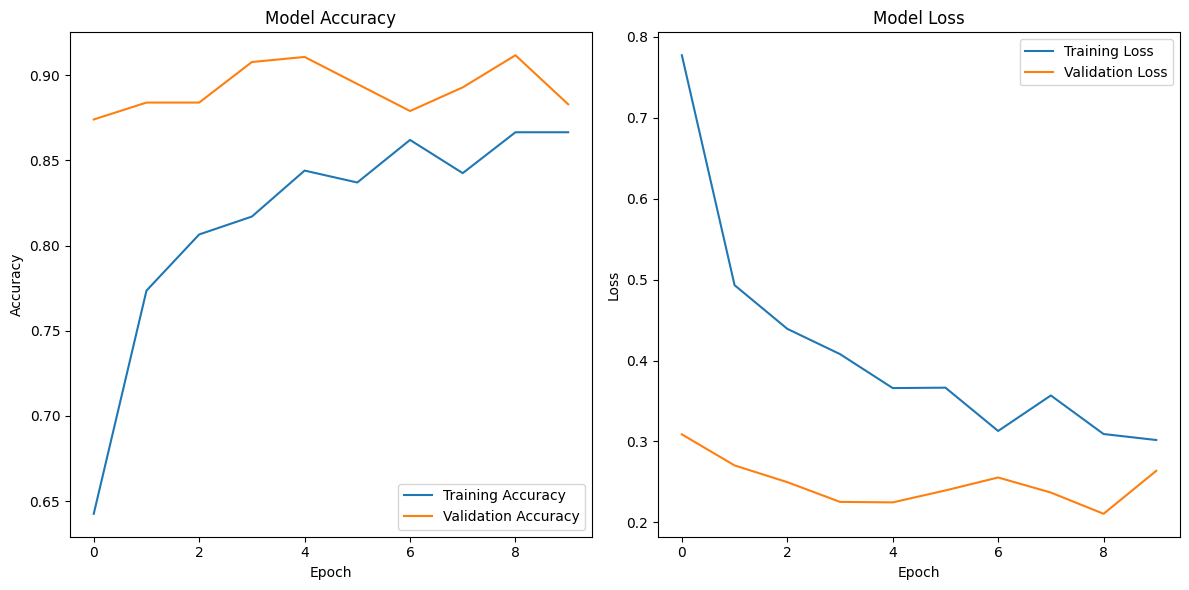

In [ ]:
# Vẽ Accuracy
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Vẽ Loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
validation_generator = validation_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(224, 224),
    batch_size=BATCH_SIZE,  # Có thể tăng batch size khi đánh giá nếu muốn
    class_mode="binary",
    shuffle=False,  # Khi testing thì không nên xáo trộn dữ liệu, vì để so sánh với nhãn thực tế
)

Found 1008 images belonging to 2 classes.


d:\School\4thYear\2ndSemester\AI\.venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


32/32 ━━━━━━━━━━━━━━━━━━━━ 92s 3s/step
Class Indices: {'cats': 0, 'dogs': 1}


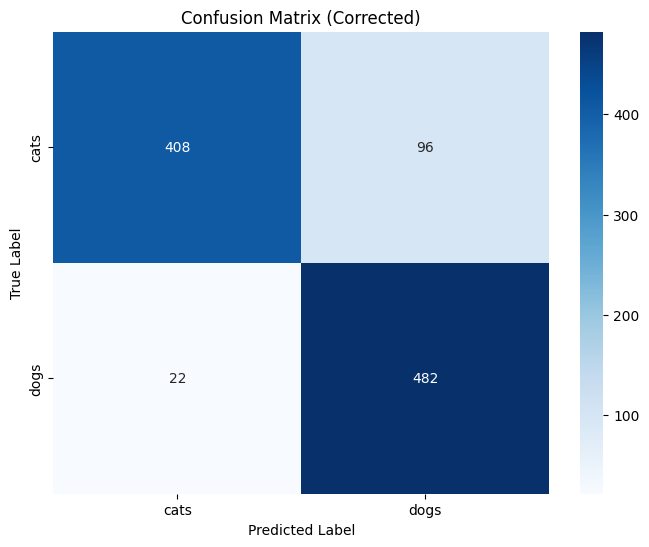

In [ ]:
# Dự đoán trên tập validation
y_pred_prob = custom_model.predict(
    validation_generator, steps=len(validation_generator), verbose=1
)  # Đổi tên để rõ ràng hơn

# Nhãn thật (true labels)
y_true = validation_generator.classes

# Kiểm tra class indices để biết 0 là gì, 1 là gì
print("Class Indices:", validation_generator.class_indices)
# Ví dụ: {'cats': 0, 'dogs': 1}

# Chuyển đổi xác suất thành lớp dự đoán (0 hoặc 1) bằng ngưỡng 0.5
threshold = 0.5
y_pred_classes = (y_pred_prob > threshold).astype(int)

# Có thể cần flatten y_pred_classes nếu nó đang là (số_lượng_mẫu, 1)
y_pred_classes = y_pred_classes.flatten()

# --- Tính và vẽ lại Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred_classes)

# Lấy tên lớp theo đúng thứ tự của chỉ số (0, 1, ...)
class_labels = list(validation_generator.class_indices.keys())

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,  # Sử dụng tên lớp đã lấy
    yticklabels=class_labels,
)  # Sử dụng tên lớp đã lấy
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Corrected)")
plt.show()

In [3]:
final_model = tf.keras.models.load_model("final_vgg16model.h5")

In [15]:
val_loss, val_accuracy = final_model.evaluate(
    validation_generator,
    steps=len(validation_generator),
    verbose=1
)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 93s 3s/step - accuracy: 0.8340 - loss: 0.3659
Validation Loss: 0.2637
Validation Accuracy: 0.8829


In [ ]:
from sklearn.metrics import classification_report

# 1. Dự đoán xác suất
y_pred_prob = final_model.predict(
    validation_generator, steps=len(validation_generator), verbose=1
)

# 2. Chuyển về nhãn 0 hoặc 1 với threshold 0.5
y_pred_classes = (y_pred_prob > 0.5).astype(int).flatten()

# 3. Lấy nhãn thực
y_true = validation_generator.classes

# 4. Lấy tên class theo đúng index
class_labels = list(validation_generator.class_indices.keys())

# 5. In classification report (Precision, Recall, F1 cho từng nhãn)
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

d:\School\4thYear\2ndSemester\AI\.venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


32/32 ━━━━━━━━━━━━━━━━━━━━ 94s 3s/step
Classification Report:
              precision    recall  f1-score   support

        cats       0.95      0.81      0.87       504
        dogs       0.83      0.96      0.89       504

    accuracy                           0.88      1008
   macro avg       0.89      0.88      0.88      1008
weighted avg       0.89      0.88      0.88      1008



### Make prediction


In [ ]:
test_frames = [
    validation_cats_dir + "\\" + frame for frame in validation_cat_frame[:5]
] + [validation_dogs_dir + "\\" + frame for frame in validation_dog_frame[:5]]

------------------------------
Processing: ../data\validation\cats\cat.1002.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
Predicted Probability (Dog): 0.0001
Predicted Label: Cat


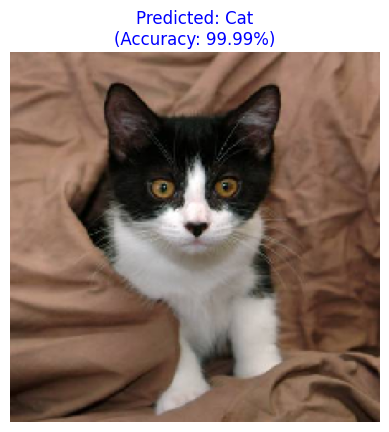

------------------------------
Processing: ../data\validation\cats\cat.1003.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
Predicted Probability (Dog): 0.8022
Predicted Label: Dog


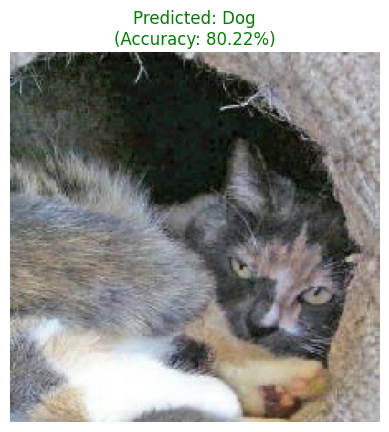

------------------------------
Processing: ../data\validation\cats\cat.1004.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
Predicted Probability (Dog): 0.5389
Predicted Label: Dog


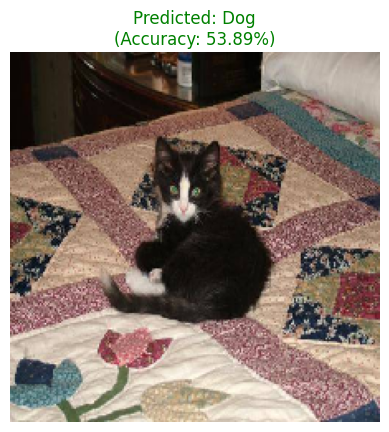

------------------------------
Processing: ../data\validation\cats\cat.1005.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
Predicted Probability (Dog): 0.0033
Predicted Label: Cat


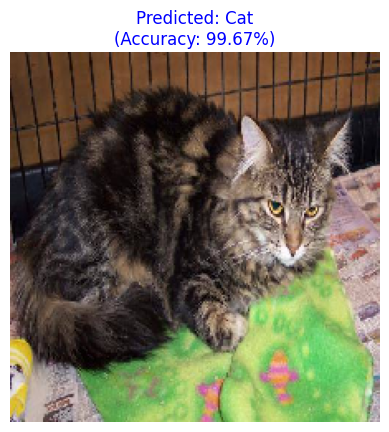

------------------------------
Processing: ../data\validation\cats\cat.1006.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
Predicted Probability (Dog): 0.4961
Predicted Label: Cat


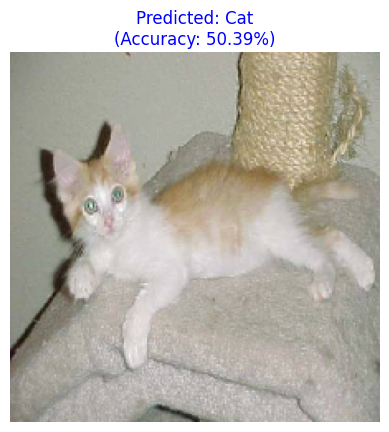

------------------------------
Processing: ../data\validation\dogs\dog.1003.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
Predicted Probability (Dog): 0.9973
Predicted Label: Dog


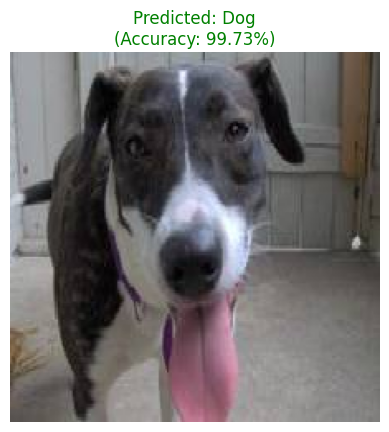

------------------------------
Processing: ../data\validation\dogs\dog.1004.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
Predicted Probability (Dog): 0.9999
Predicted Label: Dog


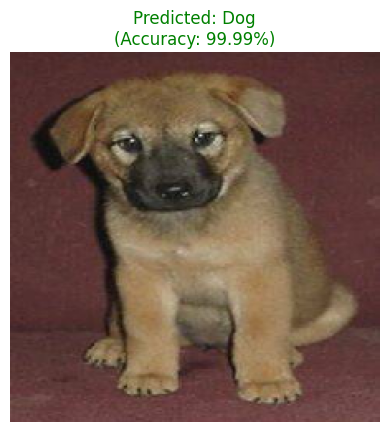

------------------------------
Processing: ../data\validation\dogs\dog.1005.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
Predicted Probability (Dog): 1.0000
Predicted Label: Dog


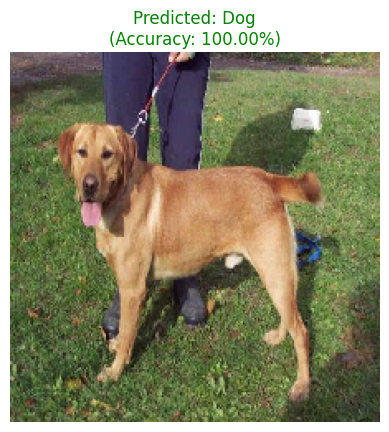

------------------------------
Processing: ../data\validation\dogs\dog.1006.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
Predicted Probability (Dog): 1.0000
Predicted Label: Dog


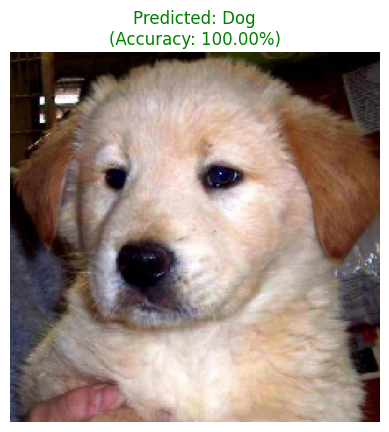

------------------------------
Processing: ../data\validation\dogs\dog.1007.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
Predicted Probability (Dog): 0.9036
Predicted Label: Dog


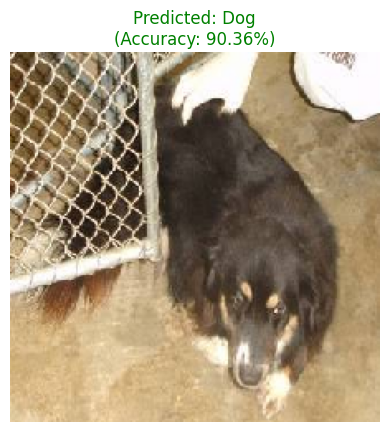

In [ ]:
for frame_path in test_frames:
    print("-" * 30)
    print(f"Processing: {frame_path}")

    try:
        # 1. Tải ảnh gốc để hiển thị (không cần chuyển thành array ngay)
        img_for_display = tf.keras.preprocessing.image.load_img(
            frame_path, target_size=(224, 224)
        )

        # 2. Chuyển ảnh thành array để chuẩn bị cho mô hình
        img_array = tf.keras.preprocessing.image.img_to_array(img_for_display)

        # 3. Thêm chiều batch
        img_batch = np.expand_dims(img_array, axis=0)

        # 4. Chuẩn hóa pixel (!!! QUAN TRỌNG: Phải giống hệt generator !!!)
        img_processed = img_batch / 255.0

        # 5. Dự đoán
        prediction = custom_model.predict(img_processed)
        prediction_prob_dog = prediction[0][0]  # Lấy xác suất là chó

        # 6. Xác định nhãn dự đoán
        threshold = 0.5
        if prediction_prob_dog > threshold:
            predicted_label = "Dog"
            predicted_prob = prediction_prob_dog  # Xác suất của chó
        else:
            predicted_label = "Cat"
            predicted_prob = (
                1 - prediction_prob_dog
            )  # Xác suất của mèo (1 - xác suất của chó)

        print(f"Predicted Probability (Dog): {prediction_prob_dog:.4f}")
        print(f"Predicted Label: {predicted_label}")

        # 7. Hiển thị ảnh và nhãn dự đoán
        plt.figure()  # Tạo một figure mới cho mỗi ảnh
        plt.imshow(img_for_display)  # Hiển thị ảnh gốc đã tải (chưa rescale)

        # Tùy chỉnh title dựa vào nhãn
        if predicted_label == "Dog":
            plt.title(
                f"Predicted: Dog\n(Accuracy: {predicted_prob * 100:.2f}%)",
                color="green",
            )
        else:
            plt.title(
                f"Predicted: Cat\n(Accuracy: {predicted_prob * 100:.2f}%)", color="blue"
            )

        plt.axis("off")
        plt.show()

    except FileNotFoundError:
        print(f"Error: File not found at {frame_path}")
    except Exception as e:
        print(f"An error occurred processing {frame_path}: {e}")